**MK Rekayasa Fitur**

**Topik:** Pembuatan Fitur

**Galih Hermawan. Prodi Teknik Informatika. UNIKOM**

---

## Pembersihan Data (Data Cleaning)

In [1]:
import pandas as pd

# Membuat DataFrame dengan data penjualan
data = {
    'nama_produk': ['Baju', 'Celana', 'Sepatu', 'Topi'],
    'harga': [100000, 150000, None, 50000],  # Nilai hilang pada harga sepatu
    'jumlah': [10, 20, 5, 15]
}

df = pd.DataFrame(data)

# Inspeksi awal data
print("Data awal:")
print(df)

# Menghitung nilai yang hilang (missing values)
print("\nJumlah nilai yang hilang:")
print(df.isnull().sum())

# Mengisi nilai yang hilang pada kolom harga dengan rata-rata harga
mean_harga = df['harga'].mean()
df['harga'].fillna(mean_harga, inplace=True)

# Menghapus baris dengan nilai yang hilang pada kolom jumlah
df.dropna(subset=['jumlah'], inplace=True)

print("\nData setelah pembersihan:")
print(df)


Data awal:
  nama_produk     harga  jumlah
0        Baju  100000.0      10
1      Celana  150000.0      20
2      Sepatu       NaN       5
3        Topi   50000.0      15

Jumlah nilai yang hilang:
nama_produk    0
harga          1
jumlah         0
dtype: int64

Data setelah pembersihan:
  nama_produk     harga  jumlah
0        Baju  100000.0      10
1      Celana  150000.0      20
2      Sepatu  100000.0       5
3        Topi   50000.0      15


## Normalisasi Data

In [2]:
# Normalisasi harga (Min-Max Scaling)
df['harga_dinormalisasi'] = (df['harga'] - df['harga'].min()) / (df['harga'].max() - df['harga'].min())

print("\nData setelah normalisasi:")
print(df)



Data setelah normalisasi:
  nama_produk     harga  jumlah  harga_dinormalisasi
0        Baju  100000.0      10                  0.5
1      Celana  150000.0      20                  1.0
2      Sepatu  100000.0       5                  0.5
3        Topi   50000.0      15                  0.0


## Representasi Numerik dari Data

In [3]:
# Menghitung statistik harga
mean_harga = df['harga'].mean()
median_harga = df['harga'].median()
std_harga = df['harga'].std()

print(f"Mean harga: {mean_harga}")
print(f"Median harga: {median_harga}")
print(f"Standar deviasi harga: {std_harga}")

# Menghitung kuartil pertama (Q1), kuartil kedua (Q2), dan kuartil ketiga (Q3) untuk kolom harga
q1_points = df['harga'].quantile(0.25)
q2_points = df['harga'].quantile(0.5)
q3_points = df['harga'].quantile(0.75)

print(f"Kuartil Pertama (Q1): {q1_points}")
print(f"Kuartil Kedua (Q2): {q2_points}")
print(f"Kuartil Ketiga (Q3): {q3_points}")


Mean harga: 100000.0
Median harga: 100000.0
Standar deviasi harga: 40824.8290463863
Kuartil Pertama (Q1): 87500.0
Kuartil Kedua (Q2): 100000.0
Kuartil Ketiga (Q3): 112500.0


## Contoh Fitur Numerik dari Data Sensor

In [4]:
# Membuat DataFrame dengan data sensor
sensor_data = {
    'suhu': [25.5, 26.0, 24.8, 27.2],
    'kelembaban': [60, 62, 58, 65],
    'tekanan': [1010, 1008, 1005, 1012]
}

sensor_df = pd.DataFrame(sensor_data)

# Ekstraksi fitur statistik
sensor_df['rata_rata_suhu'] = sensor_df['suhu'].mean()
sensor_df['deviasi_standar_suhu'] = sensor_df['suhu'].std()

#print("\nData sensor dengan fitur ekstraksi:")
#print(sensor_df)
sensor_df

,suhu,kelembaban,tekanan,rata_rata_suhu,deviasi_standar_suhu
0,25.5,60,1010,25.875,1.011187
1,26.0,62,1008,25.875,1.011187
2,24.8,58,1005,25.875,1.011187
3,27.2,65,1012,25.875,1.011187


## Pengkodean Label (Label Encoding)

In [5]:
# Membuat DataFrame dengan data warna
data = {
    'warna': ['Merah', 'Hijau', 'Biru', 'Hijau', 'Merah', 'Coklat']
}

df = pd.DataFrame(data)

# Menggunakan Label Encoding
df['warna_encoded'] = df['warna'].astype('category').cat.codes + 1

#print("Data setelah pengkodean label:")
#print(df)
df

,warna,warna_encoded
0,Merah,4
1,Hijau,3
2,Biru,1
3,Hijau,3
4,Merah,4
5,Coklat,2


## One-Hot Encoding

In [6]:
# Membuat DataFrame dengan data jenis kelamin
data_gender = {
    'jenis_kelamin': ['Pria', 'Wanita', 'Pria', 'Wanita', 'Wanita']
}

df_gender = pd.DataFrame(data_gender)

# Menggunakan One-Hot Encoding
df_one_hot = pd.get_dummies(df_gender, columns=['jenis_kelamin'], prefix=['gender'])

#print("\nData setelah one-hot encoding:")
#print(df_one_hot)
df_one_hot

,gender_Pria,gender_Wanita
0,True,False
1,False,True
2,True,False
3,False,True
4,False,True


## Contoh Konversi Fitur Kategorikal

In [7]:
# Membuat DataFrame dengan data status pernikahan
data_status = {
    'status_pernikahan': ['Menikah', 'Lajang', 'Menikah', 'Menikah', 'Lajang']
}

df_status = pd.DataFrame(data_status)

# Menggunakan Label Encoding
df_status['status_encoded'] = df_status['status_pernikahan'].astype('category').cat.codes + 1

# Menggunakan One-Hot Encoding
df_status_one_hot = pd.get_dummies(df_status, columns=['status_pernikahan'], prefix=['status'])

#print("\nData setelah konversi fitur kategorikal:")
#print(df_status_one_hot)
df_status_one_hot

,status_encoded,status_Lajang,status_Menikah
0,2,False,True
1,1,True,False
2,2,False,True
3,2,False,True
4,1,True,False


## Representasi Numerik dari Teks

In [8]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Contoh data teks
corpus = [
    "Ini adalah ulasan produk yang bagus",
    "Produk ini sangat buruk dan tidak layak",
    "Saya suka layanan pelanggan mereka"
]

# Menggunakan model Bag of Words (CountVectorizer)
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(corpus)

print("Hasil representasi numerik dengan Bag of Words:")
print(pd.DataFrame(X_bow.toarray(), columns=vectorizer_bow.get_feature_names_out()))

# Menggunakan model TF-IDF
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(corpus)

print("\nHasil representasi numerik dengan TF-IDF:")
print(pd.DataFrame(X_tfidf.toarray(), columns=vectorizer_tfidf.get_feature_names_out()))


Hasil representasi numerik dengan Bag of Words:
   adalah  bagus  buruk  dan  ini  layak  layanan  mereka  pelanggan  produk  \
0       1      1      0    0    1      0        0       0          0       1   
1       0      0      1    1    1      1        0       0          0       1   
2       0      0      0    0    0      0        1       1          1       0   

   sangat  saya  suka  tidak  ulasan  yang  
0       0     0     0      0       1     1  
1       1     0     0      1       0     0  
2       0     1     1      0       0     0  

Hasil representasi numerik dengan TF-IDF:
     adalah     bagus     buruk       dan       ini     layak   layanan  \
0  0.440362  0.440362  0.000000  0.000000  0.334907  0.000000  0.000000   
1  0.000000  0.000000  0.403016  0.403016  0.306504  0.403016  0.000000   
2  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.447214   

     mereka  pelanggan    produk    sangat      saya      suka     tidak  \
0  0.000000   0.000000  0.33490

### Contoh Fitur Teks dalam Pembelajaran Mesin

In [9]:
# Contoh data ulasan produk
reviews = [
    "Produk ini luar biasa! Saya sangat puas.",
    "Sayang sekali, produk ini tidak sesuai harapan saya.",
    "Layanan pelanggan mereka sangat baik."
]

# Menggunakan model Bag of Words (CountVectorizer)
vectorizer_sentiment = CountVectorizer()
X_sentiment = vectorizer_sentiment.fit_transform(reviews)

print("\nHasil representasi numerik untuk analisis sentimen:")
print(pd.DataFrame(X_sentiment.toarray(), columns=vectorizer_sentiment.get_feature_names_out()))



Hasil representasi numerik untuk analisis sentimen:
   baik  biasa  harapan  ini  layanan  luar  mereka  pelanggan  produk  puas  \
0     0      1        0    1        0     1       0          0       1     1   
1     0      0        1    1        0     0       0          0       1     0   
2     1      0        0    0        1     0       1          1       0     0   

   sangat  saya  sayang  sekali  sesuai  tidak  
0       1     1       0       0       0      0  
1       0     1       1       1       1      1  
2       1     0       0       0       0      0  


Dalam contoh di atas, kita menggunakan model Bag of Words (BOW) dan TF-IDF untuk mengubah teks menjadi representasi numerik.
<hr>

## Membuat Gambar Kosong dan Menambahkan Bentuk Persegi Panjang

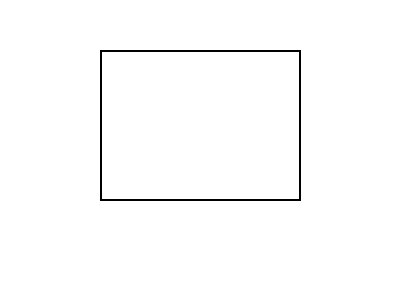

In [10]:
from PIL import Image, ImageDraw
# lib untuk menampilkan di cell notebook
from IPython.display import display 

# Membuat gambar kosong dengan latar belakang putih
gambar = Image.new('RGB', (400, 300), 'white')

# Membuat objek untuk menggambar
draw = ImageDraw.Draw(gambar)

# Menambahkan bentuk persegi panjang
draw.rectangle([100, 50, 300, 200], outline='black', width=2)

# Menyimpan gambar
#gambar.save('gambar_persegi.png')

# Menampilkan gambar
#gambar.show()

# Menampilkan gambar di Jupyter Notebook
display(gambar)

## Membuat Grafik Sederhana dengan Matplotlib

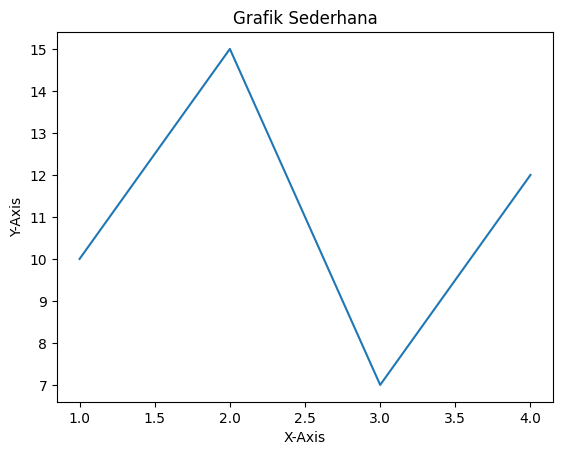

In [11]:
import matplotlib.pyplot as plt

# Data
x = [1, 2, 3, 4]
y = [10, 15, 7, 12]

# Membuat plot
plt.plot(x, y)

# Menambahkan label dan judul
plt.xlabel('X-Axis')
plt.ylabel('Y-Axis')
plt.title('Grafik Sederhana')

# Menyimpan plot sebagai gambar
plt.savefig('grafik_sederhana.png')

# Menampilkan plot
plt.show()


## Simulasi gambar wajah

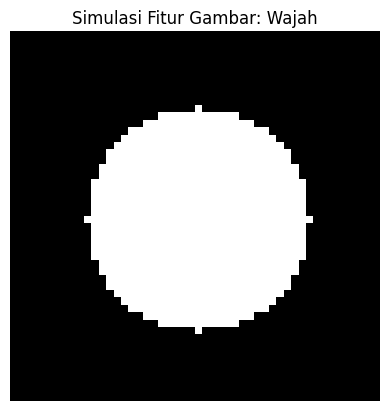

In [12]:
# Membuat gambar kotak sederhana (misalnya, wajah)
import numpy as np

ukuran_gambar = 50
gambar = np.zeros((ukuran_gambar, ukuran_gambar))

# Menggambar wajah
pusat_wajah = (25, 25)
radius_wajah = 15
for i in range(ukuran_gambar):
    for j in range(ukuran_gambar):
        if (i - pusat_wajah[0])**2 + (j - pusat_wajah[1])**2 <= radius_wajah**2:
            gambar[i, j] = 1

# Menampilkan gambar
plt.imshow(gambar, cmap='gray')
plt.title('Simulasi Fitur Gambar: Wajah')
plt.axis('off')
plt.show()

## Membuat Papan Catur

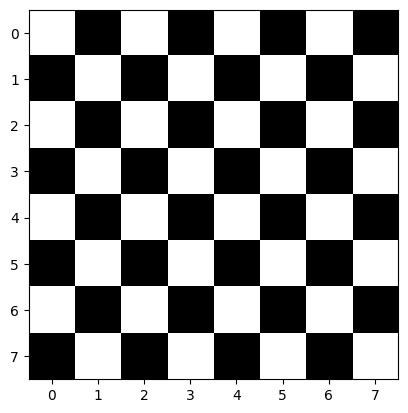

In [13]:
import matplotlib.pyplot as plt
list_warna = [[(b+k+1)%2 for b in range(8)] for k in range(8)]
plt.imshow(list_warna, cmap="gray")
plt.show()

## Gambar Wajah Sederhana

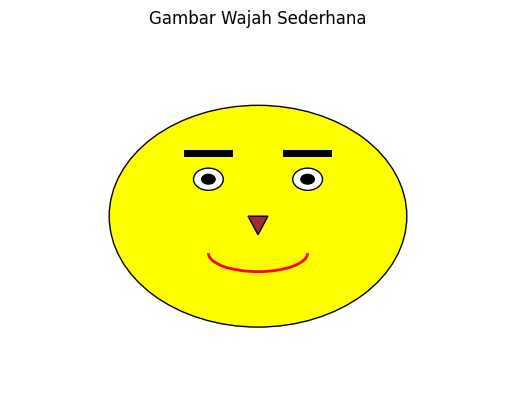

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Membuat figure dan axes
fig, ax = plt.subplots()

# Kepala
head = patches.Circle((0.5, 0.5), 0.3, facecolor='yellow', edgecolor='black')
ax.add_patch(head)

# Mata kiri
eye_left = patches.Circle((0.4, 0.6), 0.03, facecolor='white', edgecolor='black')
ax.add_patch(eye_left)
pupil_left = patches.Circle((0.4, 0.6), 0.015, facecolor='black')
ax.add_patch(pupil_left)

# Mata kanan
eye_right = patches.Circle((0.6, 0.6), 0.03, facecolor='white', edgecolor='black')
ax.add_patch(eye_right)
pupil_right = patches.Circle((0.6, 0.6), 0.015, facecolor='black')
ax.add_patch(pupil_right)

# Alis kiri
eyebrow_left = patches.Rectangle((0.35, 0.66), 0.1, 0.02, facecolor='black')
ax.add_patch(eyebrow_left)

# Alis kanan
eyebrow_right = patches.Rectangle((0.55, 0.66), 0.1, 0.02, facecolor='black')
ax.add_patch(eyebrow_right)

# Senyum
smile = patches.Arc((0.5, 0.4), 0.2, -0.1, angle=0, theta1=0, theta2=180, facecolor='none', edgecolor='red', linewidth=2)
ax.add_patch(smile)

# Hidung (opsional, bisa ditambahkan atau diubah)
nose = patches.Polygon([[0.48, 0.5], [0.52, 0.5], [0.5, 0.45]], facecolor='brown', edgecolor='black')
ax.add_patch(nose)

# Mengatur batas axes agar gambar tidak terpotong
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Menghilangkan ticks dan labels pada axes
ax.axis('off')

# Menampilkan gambar
plt.title("Gambar Wajah Sederhana")
plt.show()